<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [12]:
!pip install pandas

In [13]:
!pip install matplotlib


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [14]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-06-08 14:51:56--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  29.3MB/s    in 4.8s    

2026-06-08 14:52:01 (31.9 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



### Step 2: Import necessary libraries and load the dataset


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [16]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [17]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



In [18]:
df['JobSatPoints_6'].unique()

array([   nan,   0.  ,  25.  ,  30.  ,  60.  , 100.  ,  20.  ,  50.  ,
        15.  ,  10.  ,   5.  ,  80.  ,   8.  ,  65.  ,  90.  ,  75.  ,
        35.  ,  40.  ,  33.  ,  70.  ,  17.  ,   7.  ,  12.  ,  13.  ,
         9.  ,  21.  ,  18.  ,  95.  ,   2.  ,  45.  ,  34.  ,  16.  ,
        78.  ,  85.  ,   1.  ,  14.  ,  31.  ,  11.  ,  23.  ,  28.  ,
        81.  ,   6.25,   6.  ,  55.  ,   3.  ,  22.  ,  42.  ,   4.  ,
        89.  ,  99.  ,  12.5 ,  36.  ,  27.  ,  24.  ,  19.  ,  87.  ,
        88.  ,  29.  ,  33.33,  33.3 ,  37.  ,  39.  ,  77.  ,  68.  ,
        26.  ,  98.  ,  32.  ,  66.  ,  57.  ,  82.  ,  94.  ,  61.  ,
        43.  ,  69.  ,  76.  ,  73.  ,  17.5 ,  46.  ,  49.  ,  52.  ,
        97.  ,  96.  ,  67.  ,  91.  ,  86.  ,  56.  ,  41.  ,  74.  ,
        51.  ,  48.  ,  44.  ,  64.  ,  54.  ,  63.  ])

In [19]:
df['JobSatPoints_7'].unique()

array([    nan,   0.   ,  10.   ,  90.   ,  20.   ,  50.   ,  15.   ,
         5.   ,  60.   ,  30.   , 100.   ,   7.   ,  25.   ,  70.   ,
        65.   ,  80.   ,  33.   ,  40.   ,  35.   ,  27.   ,  23.   ,
        14.   ,  12.   ,   9.   ,   8.   ,  18.   ,  37.   ,  75.   ,
         1.   ,  11.   ,  29.   ,  17.   ,   4.   ,  21.   ,  54.   ,
        13.   ,  26.   ,  45.   ,  19.   ,   6.   ,  99.   ,   3.125,
         3.   ,  16.   ,  22.   ,  12.5  ,  85.   ,  24.   ,  55.   ,
        89.   ,  98.   ,  34.   ,  95.   ,  28.   ,   2.   ,  88.   ,
        56.   ,  32.   ,  68.   ,  77.   ,  33.33 ,  33.3  ,  39.   ,
        61.   ,  92.   ,  78.   ,  44.   ,  94.   ,  73.   ,  97.   ,
        87.   ,  81.   ,  31.   ,  18.75 ,  91.   ,  93.   ,  49.   ,
        96.   ,  83.   ,  18.5  ,  69.   ,  48.   ,  46.   ,  82.   ,
        42.   ,  51.   ,  72.   ,  86.   ,  38.   ,  67.   ,  17.5  ,
        36.   ])

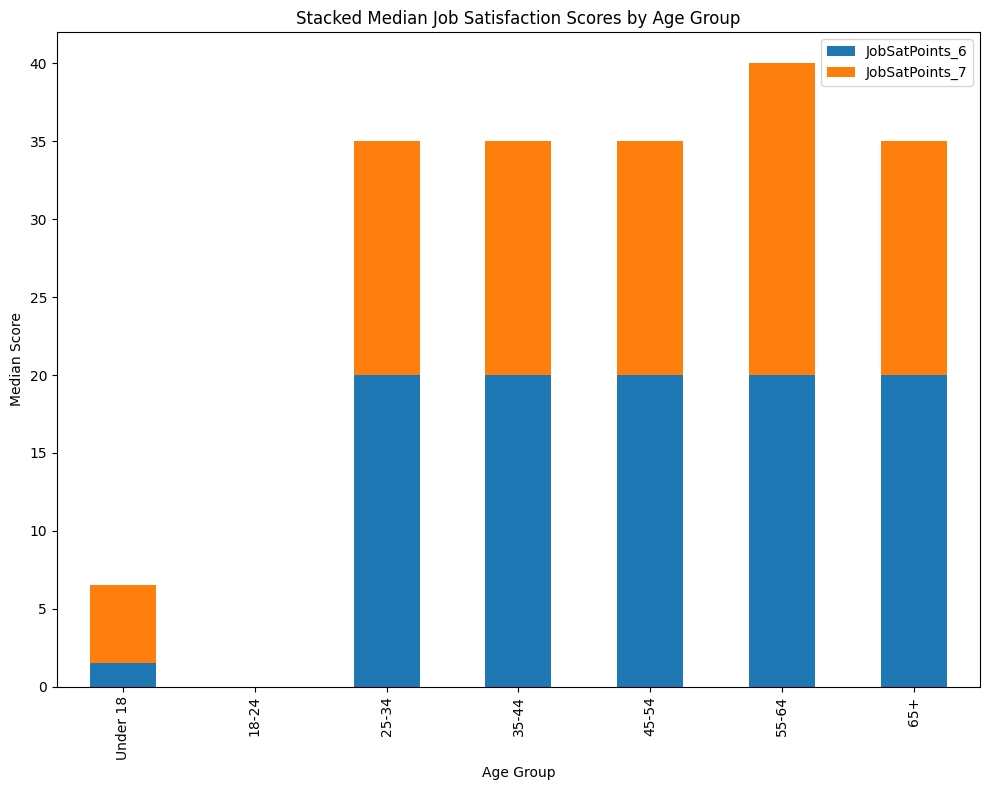

In [20]:
##Write your code here
#columns JobSatPoints_6 float, JobSatPoints_7 float , Age

age_map = {
    'Under 18 years old': 'Under 18',
    '18-24 years old': '18-21',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',    
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65+'}

df['Age_num'] = df['Age'].map(age_map)

JobSat_df = df[['JobSatPoints_6', 'JobSatPoints_7', 'Age_num']].dropna().copy()

#median values
median_data = JobSat_df.groupby('Age_num')[['JobSatPoints_6', 'JobSatPoints_7']].median()

#ensure proper order of the age groups
age_order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
median_data = median_data.reindex(age_order)

#plot stacked bar
median_data.plot(kind='bar', stacked=True, figsize=(10,8)) 

plt.title('Stacked Median Job Satisfaction Scores by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Score')
plt.legend(['JobSatPoints_6', 'JobSatPoints_7'])

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


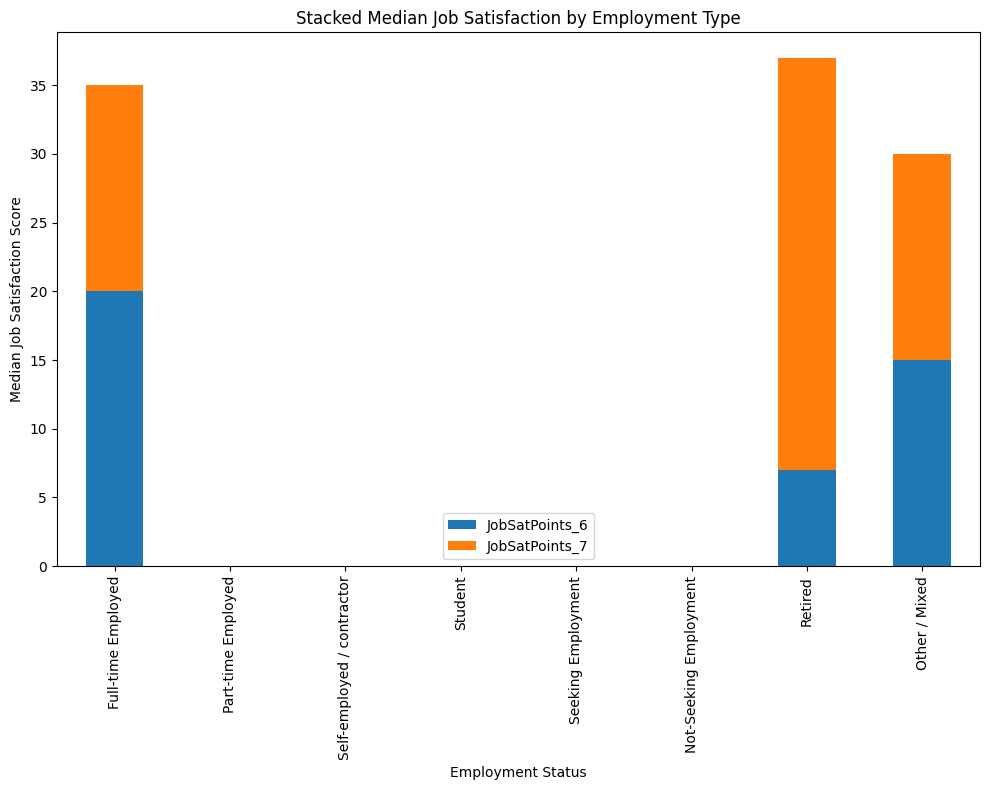

In [21]:
##Write your code here
#columns = JobSatPoints_6, JobSatPoints_7,  Employment

#Shorten Employment Labels and tidy - 
df['Employment_clean'] =( df['Employment']
.str.replace('Employed, full-time', 'Full-time Employed', regex=False)
.str.replace('Employed,part-time', 'Part-time Employed', regex=False)
.str.replace('Student,full-time', 'Full-time Student', regex=False)
.str.replace('Student,part-time', 'Part-time Student', regex=False)
.str.replace('Independentcontractor,freelancer,orself-employed', 'Self-employed / Contractor', regex=False)
.str.replace('Notemployed,butlookingforwork', 'Seeking Employment', regex=False)
.str.replace('Notemployed,andnotlookingforwork', 'Not-Seeking Employment', regex=False)
.str.replace('Retired', 'Retired', regex=False))

def simp_employment(emp):
    emp = str(emp)
    
    if 'Full-time Employed' in emp:
        return 'Full-time Employed'
    elif 'Part-time Employed' in emp:
        return 'Part-time Employed'
    elif 'Self-employed / Contractor' in emp:
        return 'Self-employed / contractor'
    elif 'Full-time Student' in emp or 'Part-time Student' in emp:
        return 'Student'
    elif 'Seeking Employment' in emp:
        return 'Seeking Employment'
    elif 'Not-Seeking Employment' in emp:
        return 'Not-Seeking Employment'
    elif 'Retired' in emp:
        return 'Retired'
    else:
        return 'Other / Mixed'

df['Employment_tidy'] = df['Employment_clean'].apply(simp_employment)

JobSatEmp_df = df[['JobSatPoints_6', 'JobSatPoints_7', 'Employment_tidy']].dropna().copy()

#aggregate using median for consistancy
emp_median = JobSatEmp_df.groupby('Employment_tidy')[['JobSatPoints_6', 'JobSatPoints_7']].median()

#order employment to improve readability
order = [
    'Full-time Employed',
    'Part-time Employed',
    'Self-employed / contractor',
    'Student',
    'Seeking Employment',
    'Not-Seeking Employment',
    'Retired',
    'Other / Mixed']

emp_median = emp_median.reindex(order)

#plot stacked bar
emp_median.plot(kind='bar', stacked=True, figsize=(10,8)) 

plt.title('Stacked Median Job Satisfaction by Employment Type')
plt.xlabel('Employment Status')
plt.ylabel('Median Job Satisfaction Score')

plt.legend(['JobSatPoints_6', 'JobSatPoints_7'])

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


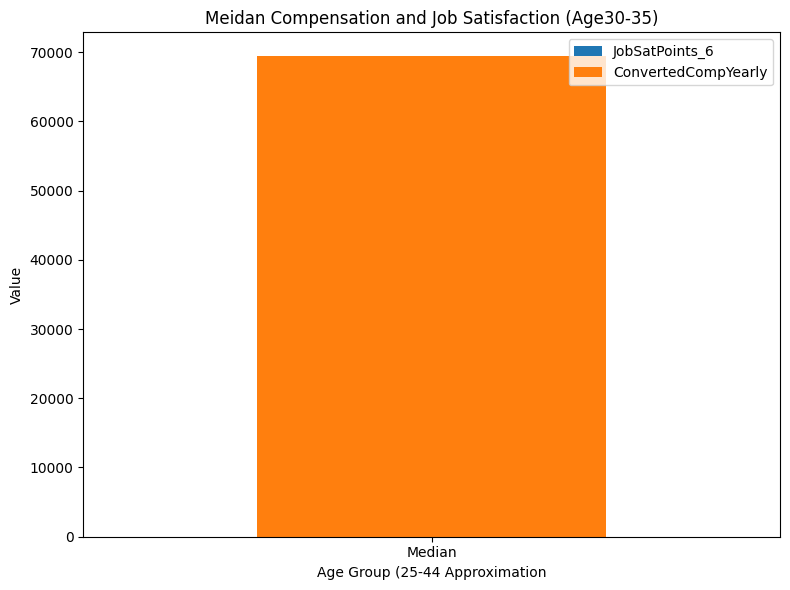

In [22]:
##Write your code here
age_map = {
    'Under 18 years old': 'Under 18',
    '18-24 years old': '18-21',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',    
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65+'}

df['Age_num'] = df['Age'].map(age_map)

JobSat_df = df[['JobSatPoints_6', 'ConvertedCompYearly', 'Age_num']].dropna().copy()

#filter to 45-60 group (using available)
JobSat_df = JobSat_df[JobSat_df['Age_num'].isin(['25-34', '35-44'])] 

#Aggregate
median_vals = JobSat_df[['JobSatPoints_6', 'ConvertedCompYearly']].median()

#convert to df for plotting
plot_df = median_vals.to_frame(name='Median').T


plot_df.plot(kind='bar', stacked=True, figsize=(8,6)) 

plt.title('Meidan Compensation and Job Satisfaction (Age30-35)')
plt.xlabel('Age Group (25-44 Approximation')
plt.ylabel('Value')

plt.legend(['JobSatPoints_6', 'ConvertedCompYearly'])

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

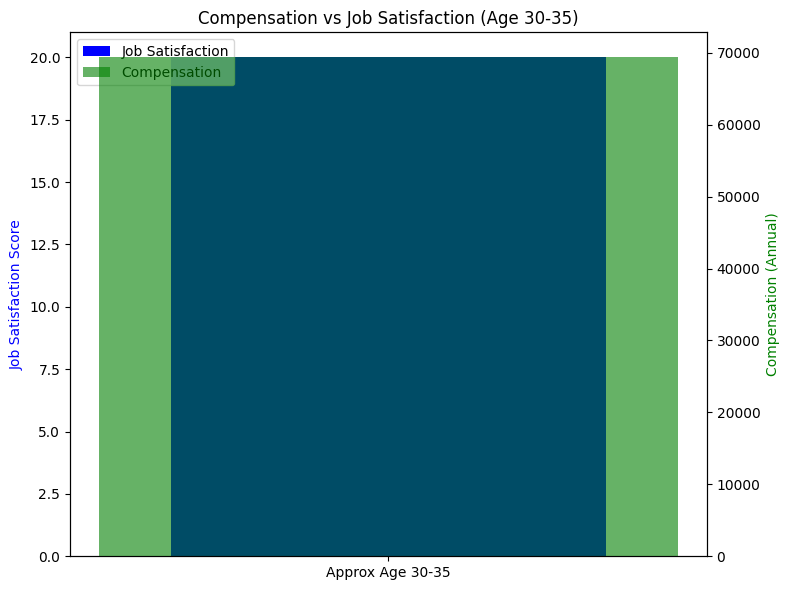

In [18]:
#This is not very helpful -as misleading and looks negligable. going to research and implement seperating axes
abs##Write your code here
age_map = {
    'Under 18 years old': 'Under 18',
    '18-24 years old': '18-21',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',    
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65+'}

df['Age_num'] = df['Age'].map(age_map)

JobSat_df = df[['JobSatPoints_6', 'ConvertedCompYearly', 'Age_num']].dropna().copy()

#filter to 45-60 group (using available)
JobSat_df = JobSat_df[JobSat_df['Age_num'].isin(['25-34', '35-44'])] 

#Aggregate
median_vals = JobSat_df[['JobSatPoints_6', 'ConvertedCompYearly']].median()

#convert to df for plotting
fig, ax1 = plt.subplots(figsize=(8, 6))

ax2 = ax1.twinx()

x_label = ['Approx Age 30-35']

#plot job satisfaction
ax1.bar(x_label, [median_vals['JobSatPoints_6']], width=0.3, color='blue', label='Job Satisfaction')

#plot compensation
ax2.bar(x_label, [median_vals['ConvertedCompYearly']], width=0.4, alpha=0.6, color='green', label='Compensation')

#labels
ax1.set_ylabel('Job Satisfaction Score', color='blue')
ax2.set_ylabel('Compensation (Annual)', color='green')

plt.title('Compensation vs Job Satisfaction (Age 30-35)')
#legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


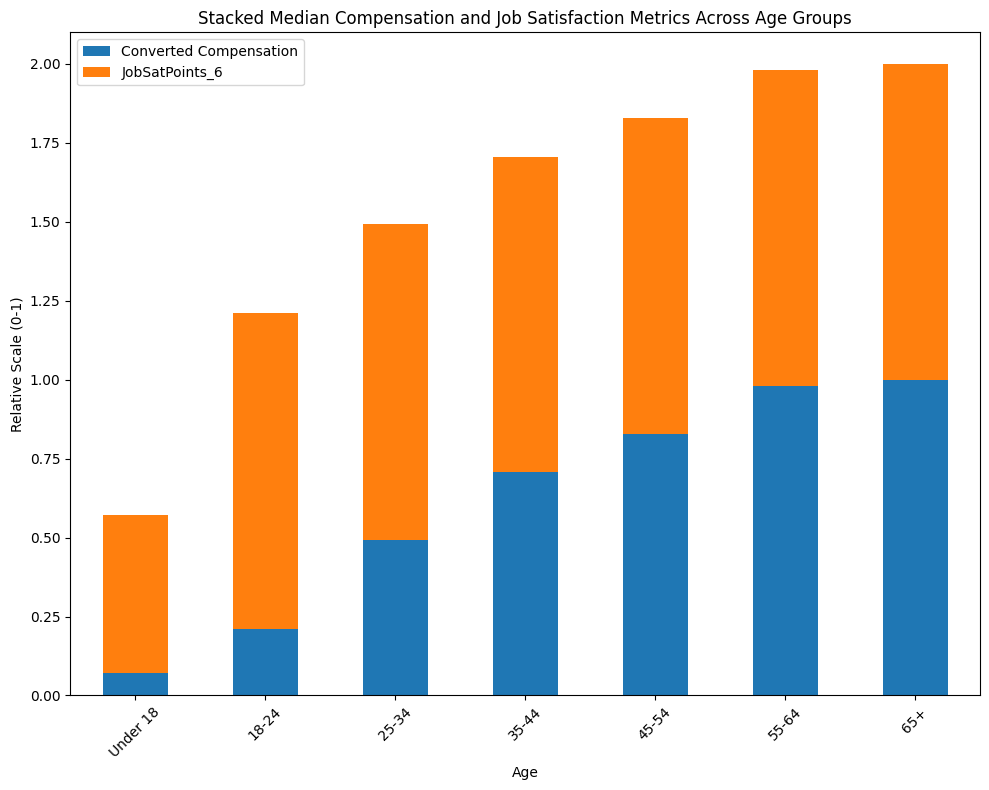

          ConvertedCompYearly  JobSatPoints_6
Age_num                                      
Under 18               8661.0            10.0
18-24                 25735.0            20.0
25-34                 59872.0            20.0
35-44                 85925.0            20.0
45-54                100900.5            20.0
55-64                119189.5            20.0
65+                  121668.0            20.0


In [23]:
##Write your code here
age_map = {
    'Under 18 years old': 'Under 18',
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',    
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65+'}

df['Age_num'] = df['Age'].map(age_map)

JobSat_df = df[['JobSatPoints_6', 'ConvertedCompYearly', 'Age_num']].dropna().copy()

median_vals = JobSat_df.groupby('Age_num')[['ConvertedCompYearly', 'JobSatPoints_6']].median()

age_order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
median_vals = median_vals.reindex(age_order)

norm_vals = median_vals / median_vals.max()

norm_vals.plot(kind='bar', stacked=True, figsize=(10,8)) 

plt.title('Stacked Median Compensation and Job Satisfaction Metrics Across Age Groups')
plt.xlabel('Age')
plt.ylabel('Relative Scale (0-1)')

plt.legend(['Converted Compensation', 'JobSatPoints_6'])

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(median_vals)

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


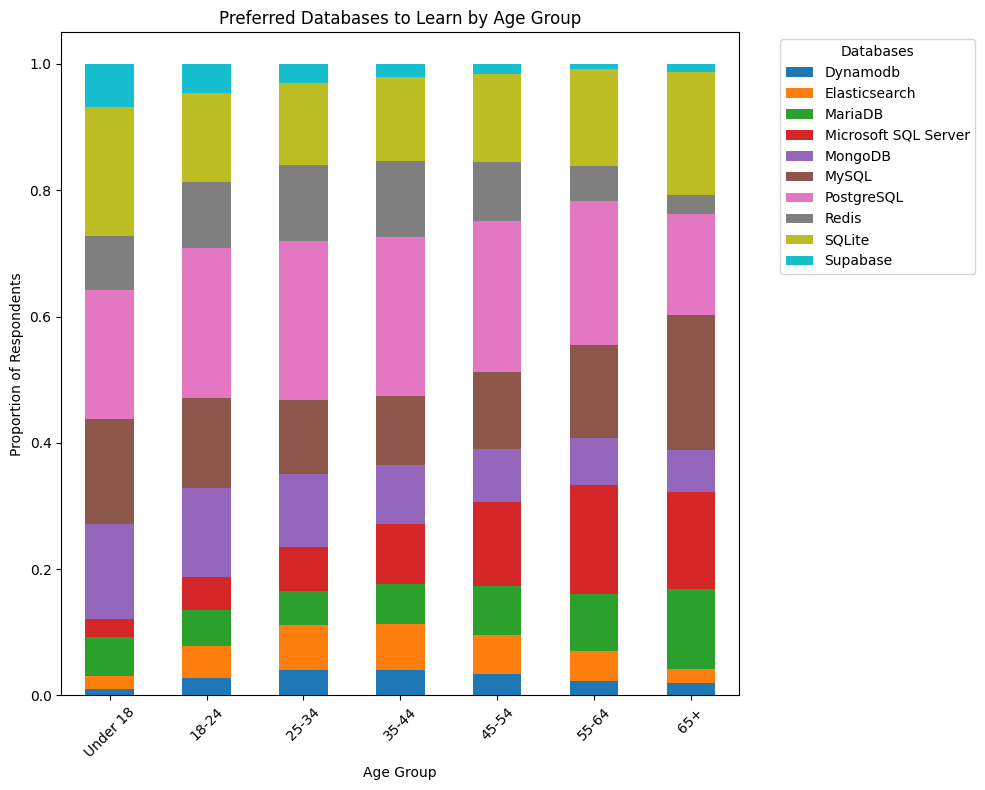

In [24]:
##Write your code here
#columns Age, DatabaseWantToWorkWith

age_map = {
    'Under 18 years old': 'Under 18',
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',    
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65+'}

df['Age_num'] = df['Age'].map(age_map)

Data_df = df[['DatabaseWantToWorkWith', 'Age_num']].dropna().copy()

Data_df['DatabaseWantToWorkWith'] = Data_df['DatabaseWantToWorkWith'].astype(str).str.strip()

#splitting into seperate rows
Data_exploded = Data_df.assign(DatabaseWantToWorkWith=Data_df['DatabaseWantToWorkWith'].str.split(';')).explode('DatabaseWantToWorkWith')

#clean more after exploding
Data_exploded['DatabaseWantToWorkWith'] = Data_exploded['DatabaseWantToWorkWith'].str.strip()

#Remove missing values
Data_exploded = Data_exploded.dropna()
Data_exploded = Data_exploded[Data_exploded['DatabaseWantToWorkWith'] != '']

#count database preferences by age groups
db_counts = (Data_exploded.groupby(['Age_num', 'DatabaseWantToWorkWith']).size().reset_index(name='Count'))

#keep top databases = aid in readable results
top_dbs = (db_counts.groupby('DatabaseWantToWorkWith')['Count'].sum().sort_values(ascending=False).head(10).index)

db_counts = db_counts[db_counts['DatabaseWantToWorkWith'].isin(top_dbs)]

#pivot to wide format
db_pivot = db_counts.pivot(index='Age_num',
                           columns='DatabaseWantToWorkWith',
                           values='Count').fillna(0)

#reordered age groups
age_order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
db_pivot = db_pivot.reindex(age_order)

#converting counts to proportions
db_prop = db_pivot.div(db_pivot.sum(axis=1), axis=0)

#plot stacked bar chart
db_prop.plot(kind='bar', stacked=True, figsize=(10,8)) 

plt.title('Preferred Databases to Learn by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion of Respondents')

plt.legend(title='Databases', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


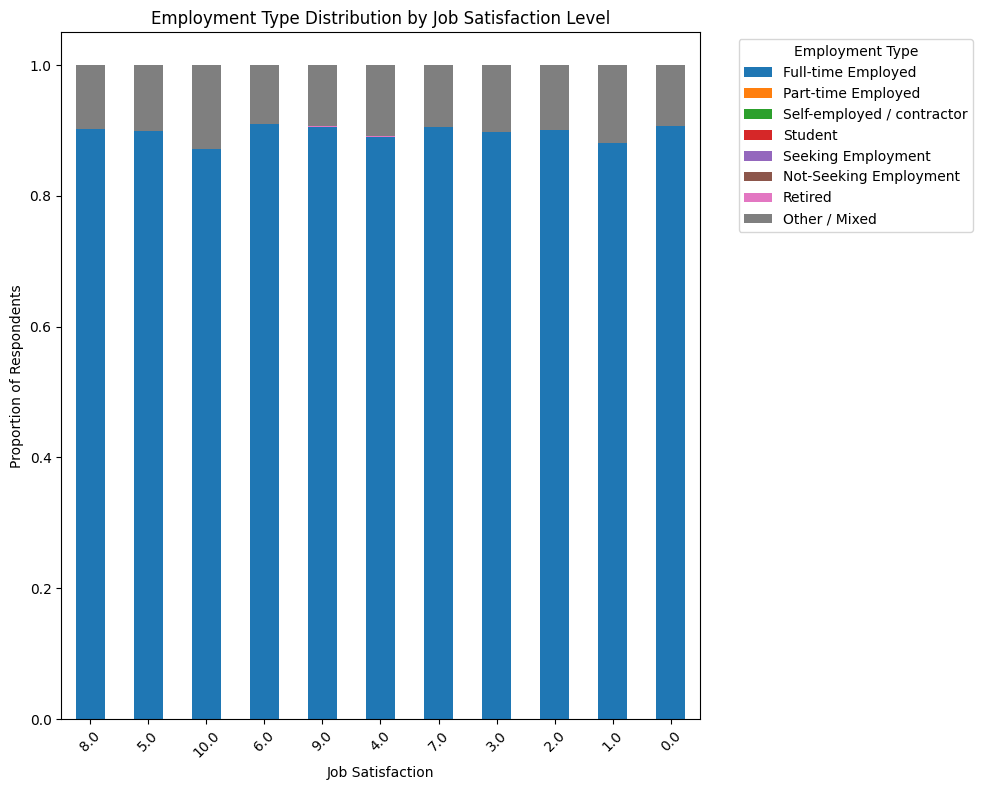

In [25]:
##Write your code here
#columns = Employment, jobsatpoints_6
#Shorten Employment Labels and tidy - 
df['Employment_clean'] =( df['Employment']
.str.replace('Employed, full-time', 'Full-time Employed', regex=False)
.str.replace('Employed,part-time', 'Part-time Employed', regex=False)
.str.replace('Student,full-time', 'Full-time Student', regex=False)
.str.replace('Student,part-time', 'Part-time Student', regex=False)
.str.replace('Independentcontractor,freelancer,orself-employed', 'Self-employed / Contractor', regex=False)
.str.replace('Notemployed,butlookingforwork', 'Seeking Employment', regex=False)
.str.replace('Notemployed,andnotlookingforwork', 'Not-Seeking Employment', regex=False)
.str.replace('Retired', 'Retired', regex=False))

def simplify_emp(emp):
    emp = str(emp)
    
    if 'Full-time Employed' in emp:
        return 'Full-time Employed'
    elif 'Part-time Employed' in emp:
        return 'Part-time Employed'
    elif 'Self-employed / Contractor' in emp:
        return 'Self-employed / contractor'
    elif 'Full-time Student' in emp or 'Part-time Student' in emp:
        return 'Student'
    elif 'Seeking Employment' in emp:
        return 'Seeking Employment'
    elif 'Not-Seeking Employment' in emp:
        return 'Not-Seeking Employment'
    elif 'Retired' in emp:
        return 'Retired'
    else:
        return 'Other / Mixed'

df['Employment_tidy'] = df['Employment_clean'].apply( simplify_emp)

JobSatEmp_df = df[['JobSat', 'Employment_tidy']].dropna().copy()

#pivot to wide format
emp_pivot = JobSatEmp_df.value_counts().unstack(fill_value=0)

#order employment to improve readability
order = [
    'Full-time Employed',
    'Part-time Employed',
    'Self-employed / contractor',
    'Student',
    'Seeking Employment',
    'Not-Seeking Employment',
    'Retired',
    'Other / Mixed']

emp_pivot = emp_pivot.reindex(columns=order)

#converting to proportions
emp_prop = emp_pivot.div(emp_pivot.sum(axis=1), axis=0)
#plot stacked chart
emp_prop.plot(kind='bar', stacked=True, figsize=(10,8)) 

plt.title('Employment Type Distribution by Job Satisfaction Level')
plt.xlabel('Job Satisfaction')
plt.ylabel('Proportion of Respondents')

plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


In [26]:
df['LanguageAdmired'].unique()


<StringArray>
[                                                                                                                     nan,
                                                  'Bash/Shell (all shells);Go;HTML/CSS;Java;JavaScript;Python;TypeScript',
                                                                                                                     'C#',
                                                              'HTML/CSS;Java;JavaScript;PowerShell;Python;SQL;TypeScript',
                                                                                     'C++;HTML/CSS;JavaScript;Lua;Python',
                                               'Bash/Shell (all shells);HTML/CSS;Java;JavaScript;Python;Swift;TypeScript',
                                                                                                                      'R',
                                                                                         'HTML/CSS;JavaScript;TypeScript',
  

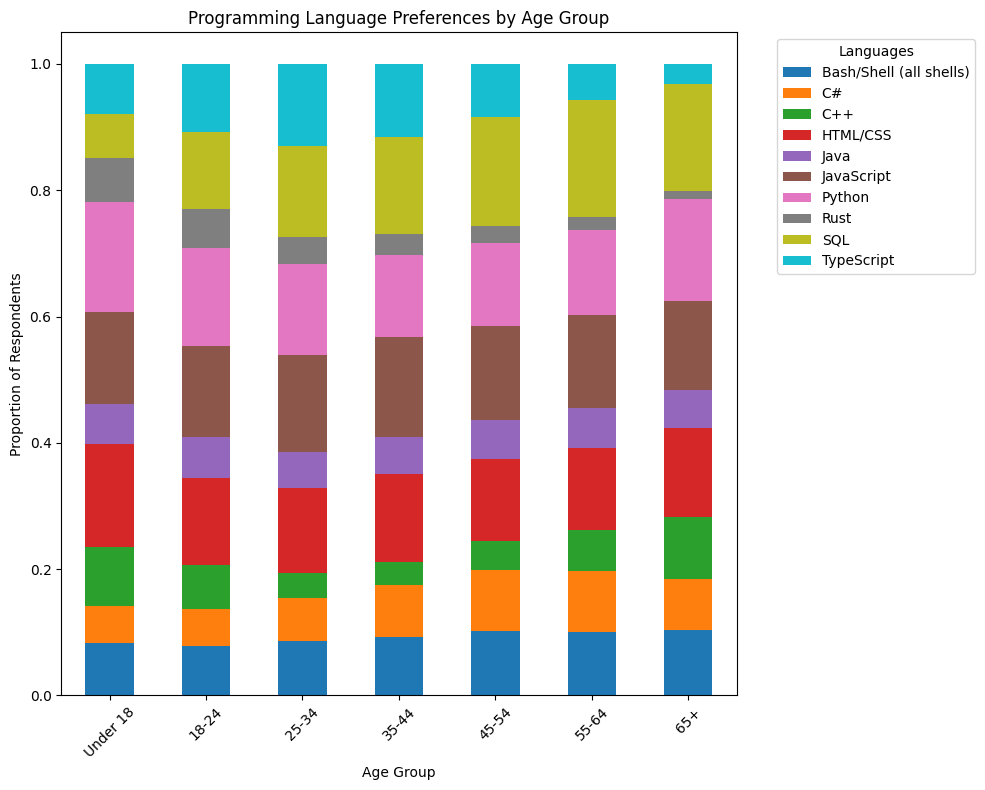

In [27]:
##Write your code here
#columns - LanguageAdmired, Age

age_map = {
    'Under 18 years old': 'Under 18',
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',    
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65+'}

df['Age_num'] = df['Age'].map(age_map)

Lang_df = df[['LanguageAdmired', 'Age_num']].dropna().copy()

Lang_df['LanguageAdmired'] = Lang_df['LanguageAdmired'].astype(str).str.strip()

#splitting into seperate rows
Lang_exploded =Lang_df.assign(LanguageAdmired=Lang_df['LanguageAdmired'].str.split(';')).explode('LanguageAdmired')

#clean more after exploding
Lang_exploded['LanguageAdmired'] = Lang_exploded['LanguageAdmired'].str.strip()

#Remove missing values
Lang_exploded = Lang_exploded.dropna()
Lang_exploded = Lang_exploded[Lang_exploded['LanguageAdmired'] != '']

#count database preferences by age groups
Lang_counts = (Lang_exploded.groupby(['Age_num', 'LanguageAdmired']).size().reset_index(name='Count'))

#keep top databases = aid in readable results
top_Lang = (Lang_counts.groupby('LanguageAdmired')['Count'].sum().sort_values(ascending=False).head(10).index)

Lang_counts = Lang_counts[Lang_counts['LanguageAdmired'].isin(top_Lang)]

#pivot to wide format
Lang_pivot = Lang_counts.pivot(index='Age_num',
                           columns='LanguageAdmired',
                           values='Count').fillna(0)

#reordered age groups
age_order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
Lang_pivot = Lang_pivot.reindex(age_order)

#converting counts to proportions
Lang_prop = Lang_pivot.div(Lang_pivot.sum(axis=1), axis=0)

#plot stacked bar chart
Lang_prop.plot(kind='bar', stacked=True, figsize=(10,8)) 

plt.title('Programming Language Preferences by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion of Respondents')

plt.legend(title='Languages', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


In [28]:
df['PlatformAdmired'].unique()

<StringArray>
[                                                                                                                                                                                                                               nan,
                                                                                                                                                                                         'Amazon Web Services (AWS);Heroku;Netlify',
                                                                                                                                                                                                                     'Google Cloud',
                                                                                                                                                                                                        'Amazon Web Services (AWS)',
                                                                      

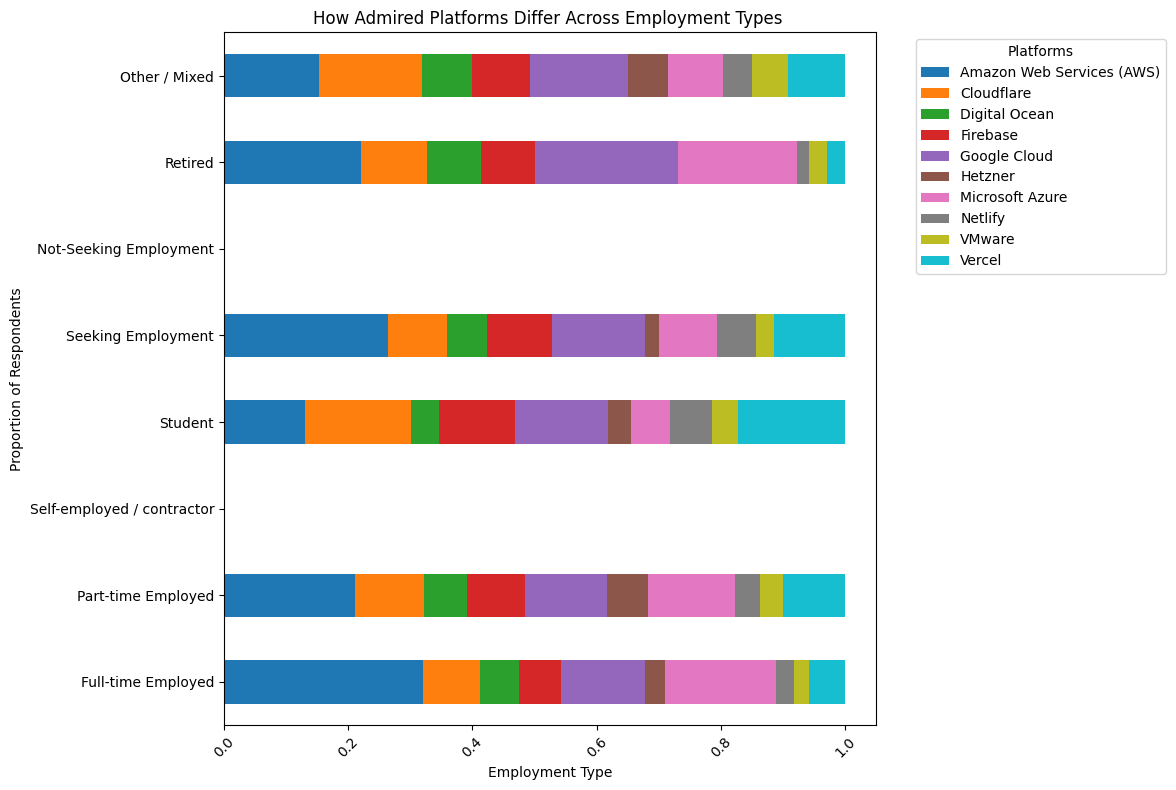

In [34]:
##Write your code here

df['Employment_clean'] =( df['Employment']
.str.replace('Employed, full-time', 'Full-time Employed', regex=False)
.str.replace('Employed,part-time', 'Part-time Employed', regex=False)
.str.replace('Student,full-time', 'Full-time Student', regex=False)
.str.replace('Student,part-time', 'Part-time Student', regex=False)
.str.replace('Independentcontractor,freelancer,orself-employed', 'Self-employed / Contractor', regex=False)
.str.replace('Notemployed,butlookingforwork', 'Seeking Employment', regex=False)
.str.replace('Notemployed,andnotlookingforwork', 'Not-Seeking Employment', regex=False)
.str.replace('Retired', 'Retired', regex=False))

def simplify_emp(emp):
    emp = str(emp)
    
    if 'full-time' in emp.lower() and 'employed' in emp.lower():
        return 'Full-time Employed'
    elif 'part-time' in emp.lower() and 'employed' in emp.lower():
        return 'Part-time Employed'
    elif 'freelancer' in emp.lower() or 'self-employed' in emp.lower():
        return 'Self-employed / Contractor'
    elif 'student' in emp.lower():
        return 'Student'
    elif 'looking for work' in emp.lower():
        return 'Seeking Employment'
    elif 'not looking' in emp.lower():
        return 'Not-Seeking Employment'
    elif 'retired' in emp.lower():
        return 'Retired'
    else:
        return 'Other / Mixed'


df['Employment_tidy'] = df['Employment_clean'].apply( simplify_emp)

platform_df = df[['PlatformAdmired', 'Employment_tidy']].dropna().copy()

platform_df['PlatformAdmired'] = platform_df['PlatformAdmired'].astype(str).str.strip()

#splitting into seperate rows
platform_exploded =platform_df.assign(PlatformAdmired=platform_df['PlatformAdmired'].str.split(';')).explode('PlatformAdmired')

#clean more after exploding
platform_exploded['PlatformAdmired'] = platform_exploded['PlatformAdmired'].str.strip()

#Remove missing values
platform_exploded = platform_exploded.dropna()
platform_exploded = platform_exploded[platform_exploded['PlatformAdmired'] != '']

#count database preferences by age groups
platform_counts = (platform_exploded.groupby(['Employment_tidy', 'PlatformAdmired']).size().reset_index(name='Count'))

#keep top databases = aid in readable results
top_platform = (platform_counts.groupby('PlatformAdmired')['Count'].sum().sort_values(ascending=False).head(10).index)

platform_counts = platform_counts[platform_counts['PlatformAdmired'].isin(top_platform)]

#pivot t.o wide format
platform_pivot = platform_counts.pivot(index='Employment_tidy',
                           columns='PlatformAdmired',
                           values='Count').fillna(0)

#reordered age groups
Employment_order = ['Full-time Employed', 'Part-time Employed', 'Self-employed / contractor', 'Student', 'Seeking Employment', 'Not-Seeking Employment', 'Retired', 'Other / Mixed']
platform_pivot = platform_pivot.reindex(Employment_order)

#converting counts to proportions
platform_prop = platform_pivot.div(platform_pivot.sum(axis=1).replace(0, 1), axis=0)

#plot stacked bar chart
platform_prop.plot(kind='barh', stacked=True, figsize=(12,8), colormap='tab10') 

plt.title('How Admired Platforms Differ Across Employment Types ')
plt.xlabel('Employment Type')
plt.ylabel('Proportion of Respondents')

plt.legend(title='Platforms', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
